# Notebook for testing aspects of the Diffusers library
Current list of sections:
1. VAE

## VAE

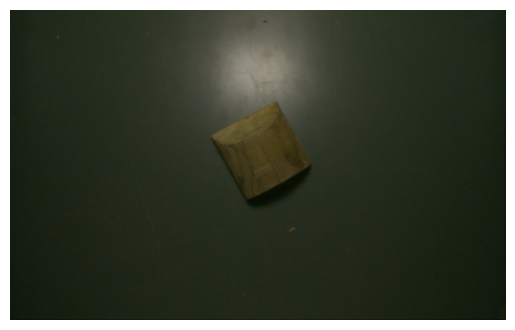

Latents shape: torch.Size([1, 4, 75, 120])
Reconstructed image shape: torch.Size([1, 3, 600, 960])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02171415..0.621067].


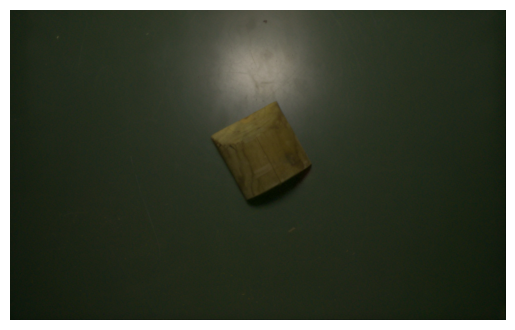

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [ ]:
# Change working directory to parent directory
import os
os.chdir("/media/aris/Data/master2025dev/aris_master")

device = "cuda"

from diffusers import AutoencoderKL

# ----------- Download model from Hugging Face and save it locally ----------- #

"""
# url = "https://huggingface.co/stabilityai/sd-vae-ft-mse-original/blob/main/vae-ft-mse-840000-ema-pruned.safetensors"  # can also be a local file
# model = AutoencoderKL.from_single_file(url)
# Save the model to current working directory
# save_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
# model.save_pretrained(save_path)

# Print files in the specified directory
# vae_directory = os.path.join(os.getcwd(), "models/VAE/")
# print("Files in VAE directory:", os.listdir(vae_directory))
"""

# # --------------------------- import model locally --------------------------- #
local_model_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
model = AutoencoderKL.from_pretrained(local_model_path)
model.to(device)

# # Test the model by printing its configuration
# print("Model configuration:", model.config)

# Test the model with image
img_path = "/media/aris/Data/master2025dev/datasets/wood/v2/train/impregnated_wood/images/img_bold-eagle_2024-11-04T16-33-09-968.png"
from PIL import Image
image = Image.open(img_path).convert("RGB")

#convert image to tensor
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((600, 960)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
image = transform(image).unsqueeze(0).to(device)

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_input.png"
#Limit image to valid range and convert to PIL
img = (image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
img = transforms.ToPILImage()(img)
img.save(save_path)


# plot image 
import matplotlib.pyplot as plt
plt.imshow((image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()
# latents = model.encode(image)


# ---------------------------------- encode ---------------------------------- #
import torch    
with torch.no_grad():
    latents = model.encode(image).latent_dist.sample()
print("Latents shape:", latents.shape)

# ---------------------------------- decode ---------------------------------- #
with torch.no_grad():
    reconstructed_image = model.decode(latents).sample
    
print("Reconstructed image shape:", reconstructed_image.shape)
# plot reconstructed image
plt.imshow((reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_output.png"
#Limit image to valid range and convert to PIL
img = (reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
reconstructed_image_pil = transforms.ToPILImage()(img)
reconstructed_image_pil.save(save_path)






model.to("cpu")


